# Backtest Demo — S&P 500 1B log returns

Same flow as `getting_started/cpi_backtest_demo.ipynb`: **LastValuePredictor**, **DartsAutoARIMAPredictor**, and **DartsChronos2Predictor** (Amazon Chronos-2 via Darts; first run downloads weights from Hugging Face).

In [1]:
import os
import sys
from pathlib import Path


def _bootstrap_sys_path() -> Path:
    if os.environ.get("AIENG_REPO_ROOT"):
        root = Path(os.environ["AIENG_REPO_ROOT"]).expanduser().resolve()
        if (root / "aieng-forecasting").is_dir():
            for sub in (root, root / "aieng-forecasting", root / "implementations"):
                s = str(sub)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return root
    seeds: list[Path] = []
    try:
        from IPython import get_ipython  # type: ignore[import-not-found]

        ip = get_ipython()
        if ip is not None:
            nb = ip.user_ns.get("__vsc_ipynb_file__")
            if nb:
                seeds.append(Path(nb).resolve().parent)
    except Exception:
        pass
    for env_key in ("PWD", "INIT_CWD", "OLDPWD"):
        v = os.environ.get(env_key)
        if v:
            try:
                seeds.append(Path(v).expanduser().resolve())
            except (OSError, ValueError):
                pass
    try:
        seeds.append(Path.cwd().resolve())
    except (FileNotFoundError, OSError):
        pass
    for seed in seeds:
        for p in (seed, *seed.parents):
            if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir():
                for sub in (p, p / "aieng-forecasting", p / "implementations"):
                    s = str(sub)
                    if s not in sys.path:
                        sys.path.insert(0, s)
                return p
    raise RuntimeError(
        "Cannot find repo root. Pick the project's .venv kernel, or set AIENG_REPO_ROOT."
    )


REPO_ROOT = _bootstrap_sys_path()

import aieng.forecasting  # noqa: F401
from aieng.forecasting.evaluation import BacktestSpec, backtest

import matplotlib.pyplot as plt
import pandas as pd
import yaml

from experiments.stock_price_forecasting_single_variable.data import (
    SP500_LOG_RETURN_SERIES_ID,
    build_sp500_log_return_service,
)
from methods.darts_arima import DartsAutoARIMAPredictor
from methods.darts_chronos2 import DartsChronos2Predictor
from methods.naive import LastValuePredictor



## 1. Register log-return series

In [ ]:
svc = build_sp500_log_return_service(refresh=False, start="2024-09-01")
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m-%d")
summary["end"] = summary["end"].dt.strftime("%Y-%m-%d")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,sp500_log_ret_1b,"S&P 500 one-business-day log return, derived f...","Yahoo Finance (^GSPC), derived",log-return,B,158,2025-09-03,2026-04-20


## 2. Load spec

In [3]:
spec_path = REPO_ROOT / "reference_specs" / "sp500_log_return_1b.yaml"
with spec_path.open() as f:
    spec = BacktestSpec.model_validate(yaml.safe_load(f))
print(spec.task.task_id, len(spec.origins()), spec.warmup)

sp500_log_return_1b 121 365


## 3. Predictors

In [4]:
naive_predictor = LastValuePredictor()
arima_predictor = DartsAutoARIMAPredictor(num_samples=500)
# Smaller Chronos-2 variant for faster download/inference; use hub_model_name="amazon/chronos-2" for the full model.
chronos_predictor = DartsChronos2Predictor(hub_model_name="autogluon/chronos-2-small")

## 4. Run backtests

In [5]:
naive_results = backtest(predictor=naive_predictor, spec=spec, data_service=svc)
arima_results = backtest(predictor=arima_predictor, spec=spec, data_service=svc)
chronos_results = backtest(predictor=chronos_predictor, spec=spec, data_service=svc)
for r in (naive_results, arima_results, chronos_results):
    print(r.predictor_id, len(r.predictions), r.mean_crps)

ValueError: No predictions were scored. All 121 candidate origins were skipped. Check that the target series covers the evaluation window and that warmup (365) is not too large.

## 5. Per-origin CRPS

In [ ]:
def frame(result, label):
    return pd.DataFrame({
        "origin": [p.as_of.date() for p in result.predictions],
        "forecast_date": [p.forecast_date.date() for p in result.predictions],
        f"point_{label}": [p.payload.point_forecast for p in result.predictions],
        f"crps_{label}": result.scores,
    }).set_index("forecast_date")

naive_df = frame(naive_results, "naive")
arima_df = frame(arima_results, "arima")
chronos_df = frame(chronos_results, "chronos2")
comparison = naive_df.join(arima_df[["point_arima", "crps_arima"]], how="inner").join(
    chronos_df[["point_chronos2", "crps_chronos2"]], how="inner"
)
comparison.head(10)

,origin,point_naive,crps_naive,point_arima,crps_arima,point_chronos2,crps_chronos2
forecast_date,,,,,,,
2026-02-03,2026-02-02,-0.004311,0.004128,-0.000562,0.004941,-0.000791,0.004636
2026-02-10,2026-02-09,0.019504,0.022814,0.000263,0.002538,0.002628,0.003772
2026-02-17,2026-02-16,0.000499,0.000532,-0.000310,0.002229,0.000214,0.001683
2026-02-24,2026-02-23,0.006916,0.000707,0.000957,0.004049,0.000210,0.004643
2026-03-03,2026-03-02,-0.004349,0.005140,0.000662,0.005966,0.000568,0.006338
2026-03-10,2026-03-09,-0.013366,0.011228,-0.000202,0.002136,-0.001342,0.002043
2026-03-17,2026-03-16,-0.006078,0.008569,0.000321,0.002269,-0.000093,0.002254
2026-03-24,2026-03-23,-0.015254,0.011504,-0.000992,0.002371,-0.001427,0.002440
2026-03-31,2026-03-30,-0.016863,0.045578,-0.016748,0.039573,-0.001183,0.025106


## 6. Plot

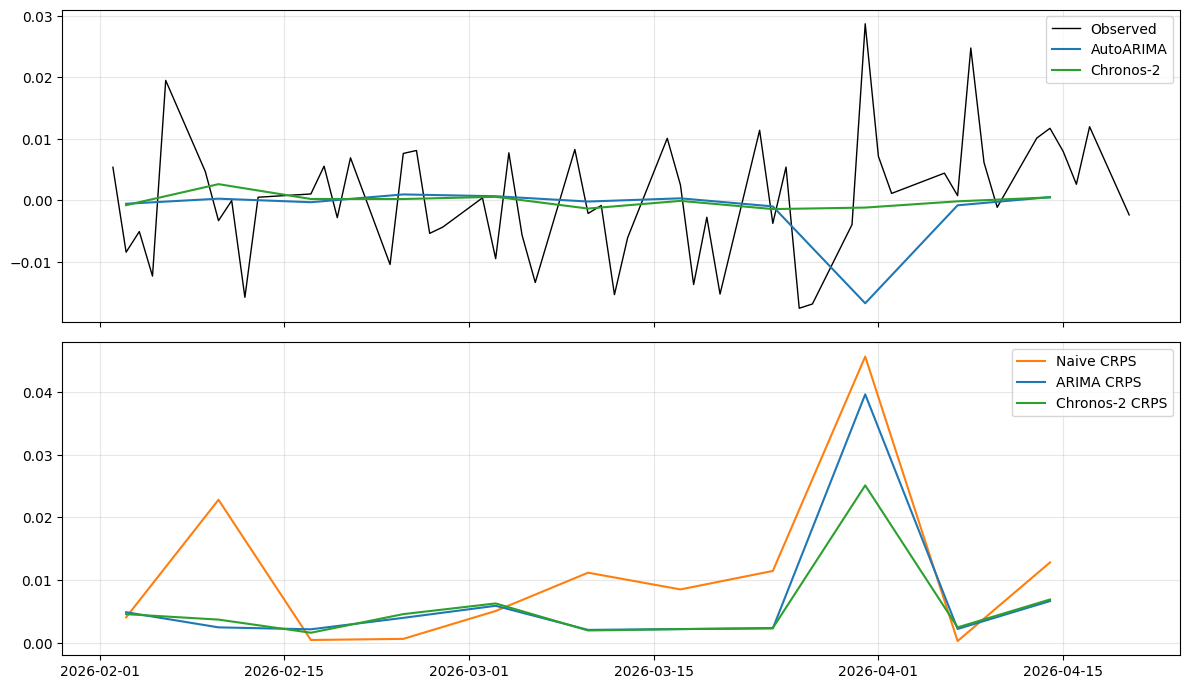

In [ ]:
target_df = svc.get_series(SP500_LOG_RETURN_SERIES_ID, as_of=pd.Timestamp("2100-01-01"))
target_df = target_df.set_index("timestamp").sort_index()
win = target_df.loc[pd.Timestamp(spec.start) : pd.Timestamp(spec.end)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(win.index, win["value"], color="black", linewidth=1, label="Observed")
ad = [p.forecast_date for p in arima_results.predictions]
ax1.plot(ad, [p.payload.point_forecast for p in arima_results.predictions], color="tab:blue", label="AutoARIMA")
ax1.plot(ad, [p.payload.point_forecast for p in chronos_results.predictions], color="tab:green", label="Chronos-2")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(ad, naive_results.scores, color="tab:orange", label="Naive CRPS")
ax2.plot(ad, arima_results.scores, color="tab:blue", label="ARIMA CRPS")
ax2.plot(ad, chronos_results.scores, color="tab:green", label="Chronos-2 CRPS")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()